#### Test VeriX on MNIST and GTSRB datasets

In [1]:
import sys

print("Python:", sys.executable)

try:
    import onnx
    print("onnx OK")
except Exception as e:
    print("onnx FAILED:", e)

try:
    import onnxruntime
    print("onnxruntime OK")
except Exception as e:
    print("onnxruntime FAILED:", e)

Python: /Users/lkiern/XAI_Framework/.venv/bin/python
onnx OK
onnxruntime OK


#### Actual test

In [2]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
from keras.datasets import mnist
from keras.losses import CategoricalCrossentropy, BinaryCrossentropy,SparseCategoricalCrossentropy
from keras.optimizers import Adam

import tf2onnx

import pickle
from keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator

from VeriX_FFA3 import *


/Users/lkiern/XAI_Framework/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Instructions for updating:
non-resource variables are not supported in the long term


In [11]:

"""
download and process MNIST data.
"""
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255




In [12]:

"""
 train your own MNIST model.
Note: to obtain sound and complete explanations, train the model from logits directly.
"""
# model_name = 'mnist-10x2'
# model = Sequential(name=model_name)
# model.add(Flatten(input_shape=(28, 28, 1)))
# model.add(Dense(10, activation='relu'))
# model.add(Dense(10, activation='relu'))
# model.add(Dense(10))
# model.summary()
# model.compile(loss=CategoricalCrossentropy(from_logits=True),
#               optimizer=Adam(learning_rate=0.001),
#               metrics=['accuracy'])
# model.fit(x_train, y_train,
#           batch_size=128,
#           epochs=20,
#           verbose=1,
#           validation_data=(x_test, y_test))
# score = model.evaluate(x_test, y_test, verbose=0)
# print("Test loss:", score[0])
# print("Test accuracy:", score[1])
# # model.save('models/' + model_name + '.h5')
# model_proto, _ = tf2onnx.convert.from_keras(model, output_path='models/' + model_name + '.onnx')



'\n train your own MNIST model.\nNote: to obtain sound and complete explanations, train the model from logits directly.\n'

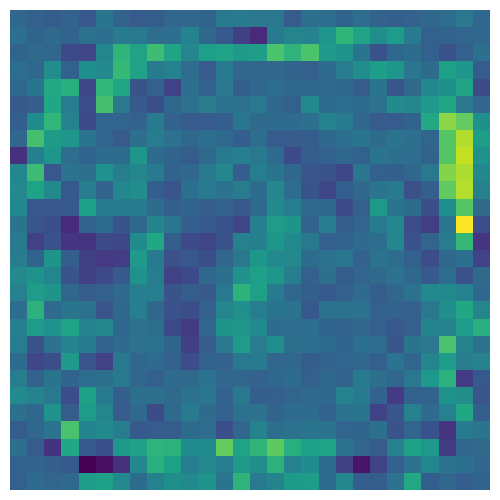

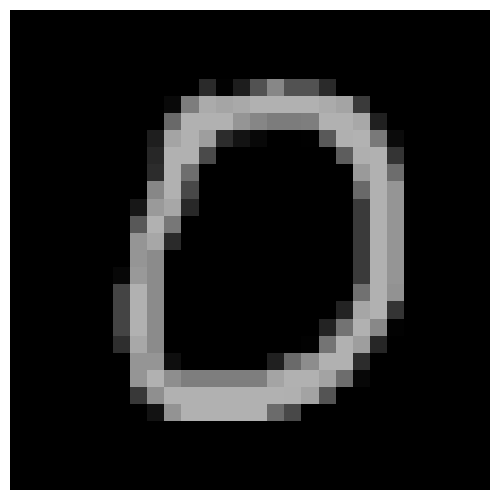

In [13]:

"""
show a simple example usage of VeriX.
"""
verix = VeriX(datatype="greyscale",
              instance=x_test[10],
              model_path="models/mnist-10x2.onnx",in_jupyter=True)
verix.traversal_order(traverse="heuristic")
verix.get_explanation(epsilon=0.05)


 This worked (check the explanation-154.png and greyscale-sensitivity-heuristic.png and original-predicted-as-0.png

#### Now test rgb

In [7]:
gtsrb_path = 'models/gtsrb.pickle'
with open(gtsrb_path, 'rb') as handle:
    gtsrb = pickle.load(handle)
x_train, y_train = gtsrb['x_train'], gtsrb['y_train']
x_test, y_test = gtsrb['x_test'], gtsrb['y_test']
x_valid, y_valid = gtsrb['x_valid'], gtsrb['y_valid']
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
y_valid = to_categorical(y_valid, 10)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
x_valid = x_valid.astype('float32') / 255
gtsrb_labels = ['50 mph', '30 mph', 'yield', 'priority road',
                'keep right', 'no passing for large vechicles', '70 mph', '80 mph',
                'road work', 'no passing']


In [8]:
# model_name = 'gtsrb-10x2'
# model = Sequential(name=model_name)
# model.add(Flatten(input_shape=(32, 32, 3)))
# model.add(Dense(10, activation='relu'))
# model.add(Dense(10, activation='relu'))
# model.add(Dense(10))
# model.summary()
# model.compile(loss=CategoricalCrossentropy(from_logits=True),
#               optimizer=Adam(learning_rate=0.001),
#               metrics=['accuracy'])
# datagen = ImageDataGenerator()
# model.fit(datagen.flow(x=x_train, y=y_train, batch_size=64),
#           steps_per_epoch=100,
#           epochs=30,
#           validation_data=(x_valid, y_valid),
#           shuffle=1)
# score = model.evaluate(x_test, y_test, verbose=0)
# print("Test loss:", score[0])
# print("Test accuracy:", score[1])
# # model.save('models/' + model_name + '.h5')
# model_proto, _ = tf2onnx.convert.from_keras(model, output_path='models/' + model_name + '.onnx')

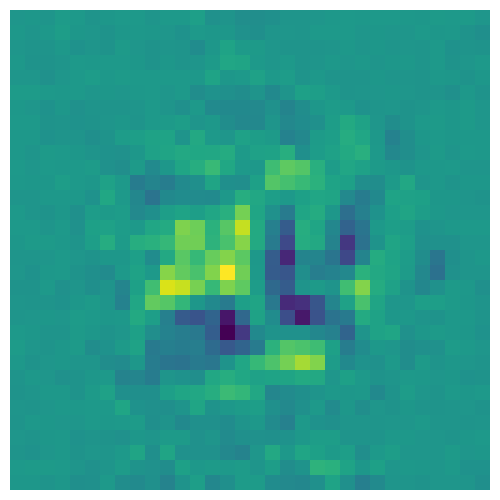

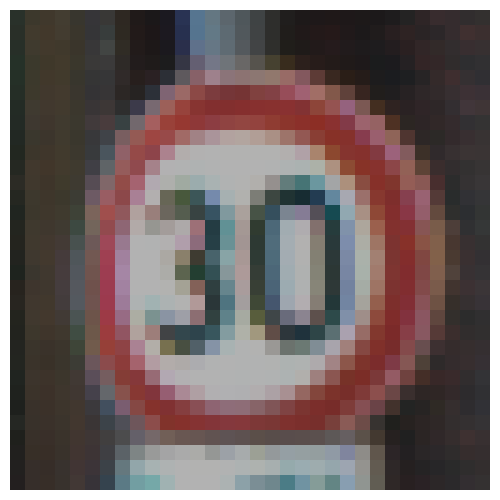

In [9]:
verix = VeriX(datatype="rgb",
              instance=x_test[0],
              model_path="models/gtsrb-10x2.onnx",in_jupyter=True)
verix.traversal_order(traverse="heuristic")
verix.get_explanation(epsilon=0.01)